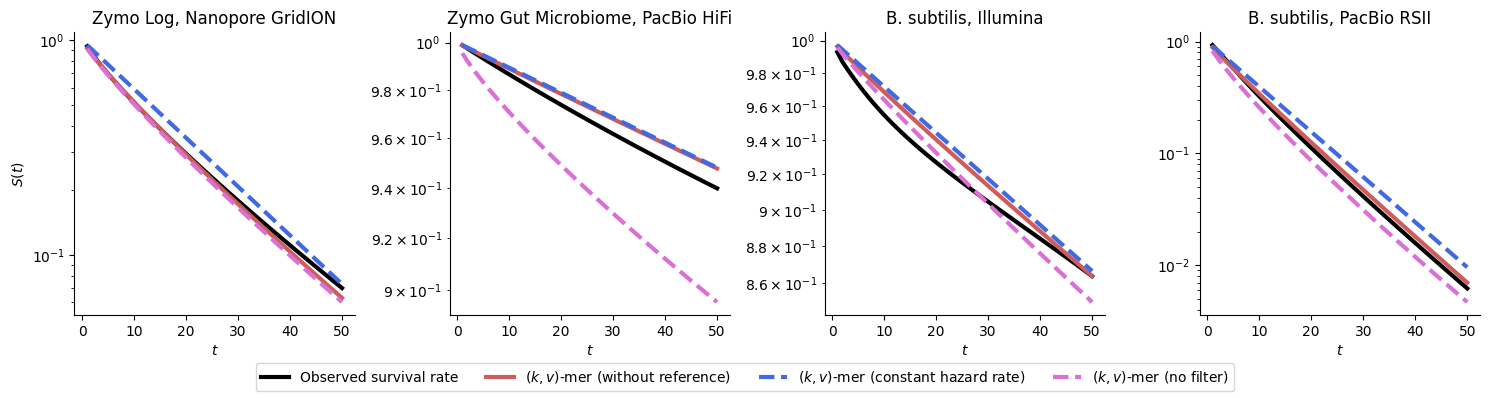

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer.csv"
    
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_const.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_const.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_const.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_const.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer_ref.csv"
]

kvmer_no_filt_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_no_filt.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_no_filt.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_no_filt.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_no_filt.csv",
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.997772,
    0.992763,
    0.868784,
    
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    82.9,
    27.7,
    9.0,
    
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.785707,
    0.613276,
    11.7262,
    
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

weibull_fit_results_no_filt = []
for i in range(len(kvmer_no_filt_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_no_filt_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_no_filt.append((a, b))

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(l, b, k):
    return np.exp(- l * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 51)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    
        
        
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    survival_rates_no_filt = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rate_no_filt = estimate_survival_rate_from_weibull(weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
        survival_rates_no_filt.append(survival_rate_no_filt)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    #axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    #axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    #axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (constant hazard rate)', color='royalblue')
    axes[i].plot(plot_range, survival_rates_no_filt, linewidth=3, linestyle='--', label='$(k,v)$-mer (no filter)', color='orchid')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/metagenomics_ablation_study.pdf")
#plt.ylim(0, 0.05)

In [7]:
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_results_ref = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]
weibull_results_no_filt = [1 - np.exp(-weibull_fit_results_no_filt[i][0]) for i in range(len(weibull_fit_results_no_filt))]

results_df = pd.DataFrame({
    "kvmer": weibull_results,
    "kvmer constant": weibull_results_ref,
    "kvmer no filter": weibull_results_no_filt,
})
results_df 

,kvmer,kvmer constant,kvmer no filter
0,0.082187,0.050997,0.087169
1,0.001160,0.001065,0.004485
2,0.003637,0.002868,0.004402
3,0.112971,0.088772,0.173049


[(0.010953, 0.898391), (0.041116, 0.856922), (0.002238, 0.888584)]


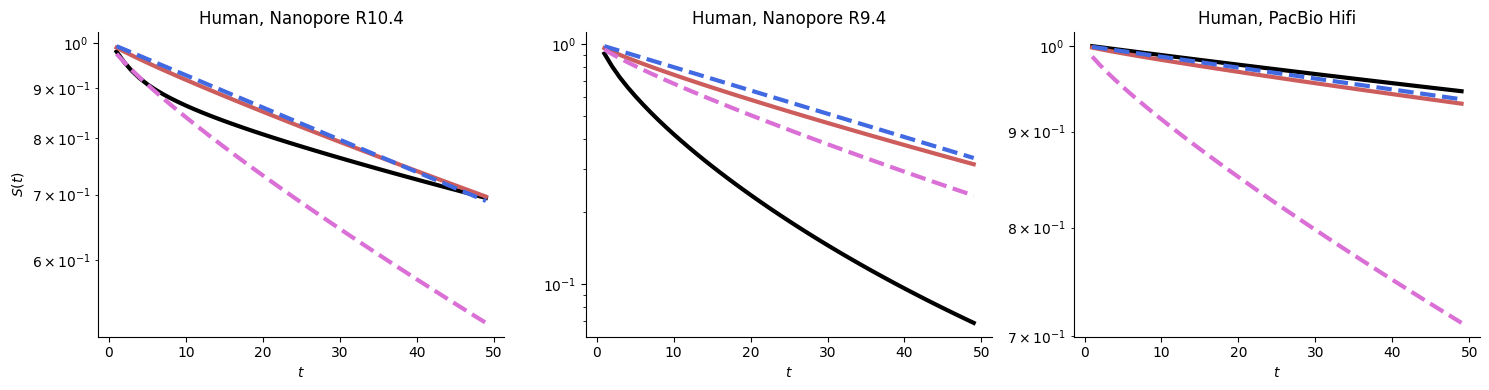

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_R941.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv",
]


labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_report_csv = [
    "../../output/human/HG002_bi_kvmer.csv",
    "../../output/human/HG002_R941_bi_kvmer.csv",
    "../../output/human/HG002_hifi_bi_kvmer.csv",
]

kvmer_ref_report_csv = [
    "../../output/human/HG002_bi_kvmer_const.csv",
    "../../output/human/HG002_R941_bi_kvmer_const.csv",
    "../../output/human/HG002_hifi_bi_kvmer_const.csv",
]

kvmer_no_filt_report_csv = [
    "../../output/human/HG002_bi_kvmer_no_filt.csv",
    "../../output/human/HG002_R941_bi_kvmer_no_filt.csv",
    "../../output/human/HG002_hifi_bi_kvmer_no_filt.csv",
]





mapping_results = [
    # Reported mapping identity by minimap2
    0.963613, # R10.4
    0.838991, # r9.4.1
    0.998709 # hifi
]

q_score_results = [
    # Reported ErrQ by seqtk
    30.1, # R10.4
    19.6, # R9.4.1
    38.5 # hifi
]

kmer_results = [
    # Reported error rate by GenomeScope
    1.076, # R10.4
    5.18148, # R9.4.1
    0.0814363, #hifi
]


weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

weibull_fit_results_no_filt = []
for i in range(len(kvmer_no_filt_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_no_filt_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_no_filt.append((a, b))

print(weibull_fit_results)

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 50)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    survival_rates_no_filt = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rate_no_filt = estimate_survival_rate_from_weibull(weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
        survival_rates_no_filt.append(survival_rate_no_filt)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    #axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    #axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    #axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (constant hazard rate)', color='royalblue')
    axes[i].plot(plot_range, survival_rates_no_filt, linewidth=3, linestyle='--', label='$(k,v)$-mer (no filter)', color='orchid')

   
    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
#fig.legend(handles, labels, loc='lower center', ncol=6)
#fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/human_ablation_study.pdf")
#plt.ylim(0, 0.05)

In [9]:
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_results_ref = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]
weibull_results_no_filt = [1 - np.exp(-weibull_fit_results_no_filt[i][0]) for i in range(len(weibull_fit_results_no_filt))]

results_df = pd.DataFrame({
    "kvmer": weibull_results,
    "kvmer constant": weibull_results_ref,
    "kvmer no filter": weibull_results_no_filt,
})
results_df 

,kvmer,kvmer constant,kvmer no filter
0,0.010893,0.007554,0.025170
1,0.040282,0.022086,0.053240
2,0.002235,0.001340,0.013144
